In [1]:
import pandas as pd
import nltk

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/IMDB-Dataset.csv")

In [4]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [5]:
df = df.drop("sentiment",axis=1)

In [6]:
df

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."
...,...
49995,I thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...


In [7]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [8]:
lemmatizer = WordNetLemmatizer()

In [9]:
def preprocess_review(text):
    if pd.isna(text):
        return ""

    # Remove HTML tags first
    text = re.sub(r'<.*?>', ' ', text)

    # Keep only alphabets
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Lowercase
    text = text.lower()

    # Tokenize
    words = text.split()

    # Remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in set(stopwords.words('english'))]

    return ' '.join(words)

In [11]:
df['clean_review'] = df['review'].apply(preprocess_review)

In [10]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [12]:
df

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...
...,...,...
49995,I thought this movie did a down right good job...,thought movie right good job creative original...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",bad plot bad dialogue bad acting idiotic direc...
49997,I am a Catholic taught in parochial elementary...,catholic taught parochial elementary school nu...
49998,I'm going to have to disagree with the previou...,going disagree previous comment side maltin on...


In [13]:
!pip install textblob

In [14]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

df['predicted_sentiment'] = df['clean_review'].apply(get_sentiment)

In [15]:
df

,review,clean_review,predicted_sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,Neutral
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,Positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,Positive
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...,Neutral
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,Positive
...,...,...,...
49995,I thought this movie did a down right good job...,thought movie right good job creative original...,Positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",bad plot bad dialogue bad acting idiotic direc...,Negative
49997,I am a Catholic taught in parochial elementary...,catholic taught parochial elementary school nu...,Neutral
49998,I'm going to have to disagree with the previou...,going disagree previous comment side maltin on...,Neutral


In [16]:
df['predicted_sentiment'].value_counts()

,count
predicted_sentiment,
Positive,24725
Neutral,19675
Negative,5600


In [17]:
pip install rake-nltk

In [19]:
from rake_nltk import Rake

In [20]:
rake = Rake()

In [21]:
def extract_rake_keywords(text, top_n=5):
    rake.extract_keywords_from_text(text)
    keywords = rake.get_ranked_phrases()
    return keywords[:top_n]


In [24]:
df['rake_keywords'] = df['clean_review'].apply(extract_rake_keywords)

In [23]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [25]:
df

,review,clean_review,predicted_sentiment,rake_keywords
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,Neutral,[one reviewer mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,Positive,[wonderful little production filming technique...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,Positive,[thought wonderful way spend time hot summer w...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...,Neutral,[basically family little boy jake think zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,Positive,[petter mattei love time money visually stunni...
...,...,...,...,...
49995,I thought this movie did a down right good job...,thought movie right good job creative original...,Positive,[thought movie right good job creative origina...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",bad plot bad dialogue bad acting idiotic direc...,Negative,[bad plot bad dialogue bad acting idiotic dire...
49997,I am a Catholic taught in parochial elementary...,catholic taught parochial elementary school nu...,Neutral,[catholic taught parochial elementary school n...
49998,I'm going to have to disagree with the previou...,going disagree previous comment side maltin on...,Neutral,[going disagree previous comment side maltin o...


In [26]:
from collections import Counter

def top_preferences(sentiment, n=10):
    keywords = []
    for kws in df[df['predicted_sentiment'] == sentiment]['rake_keywords']:
        keywords.extend(kws)
    return Counter(keywords).most_common(n)


In [27]:
print("Positive Preferences:")
print(top_preferences("Positive"))

print("\nNegative Preferences:")
print(top_preferences("Negative"))

print("\nNeutral Preferences:")
print(top_preferences("Neutral"))


Positive Preferences:
[('loved today show variety solely cooking would great stimulating captivating always keeping viewer peeking around corner see coming next earth personable get like one u made show enjoyable special guest friend well made nice surprise loved first theme audience invited play along must admit shocked see come time limit thing golly writing recipe saving time kitchen mean time family tuned yet find channel time assure disappointed', 5), ('hilarious clean light hearted quote worthy else ask film time number one favorite movie ever since little girl dreamed owning blue van flame observation bubble clich character ridiculous situation make film great fun wonderful comedic chemistry stephen furst harold andy tennant melio make favorite part movie love hopeless awkwardness flynch forget airport antic leon crony dressed hari krishna dancing chanting playing tambourine unbeatable clue genius location classic plot timeless word wise watch film little probably win place hear

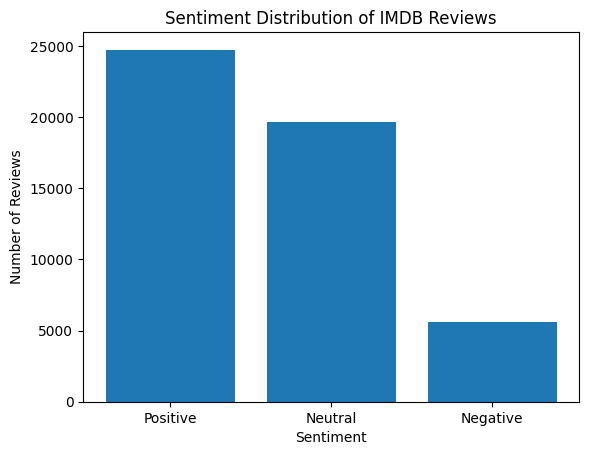

In [28]:
import matplotlib.pyplot as plt

sentiment_counts = df['predicted_sentiment'].value_counts()

plt.figure()
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution of IMDB Reviews")
plt.show()


In [29]:
pip install wordcloud

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [31]:
def generate_wordcloud(keywords, title):
    text = " ".join(keywords)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure()
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()


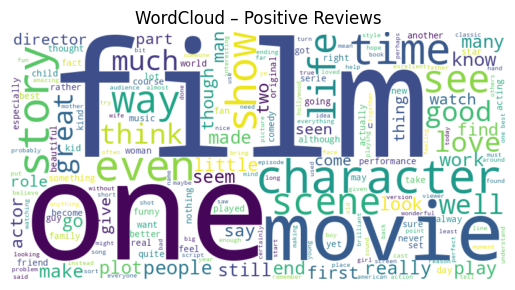

In [32]:
positive_keywords = []
for kws in df[df['predicted_sentiment'] == 'Positive']['rake_keywords']:
    positive_keywords.extend(kws)

generate_wordcloud(positive_keywords, "WordCloud – Positive Reviews")

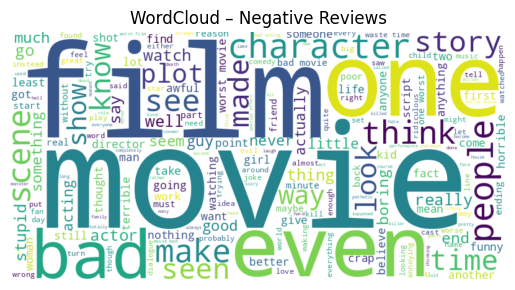

In [33]:
negative_keywords = []
for kws in df[df['predicted_sentiment'] == 'Negative']['rake_keywords']:
    negative_keywords.extend(kws)

generate_wordcloud(negative_keywords, "WordCloud – Negative Reviews")

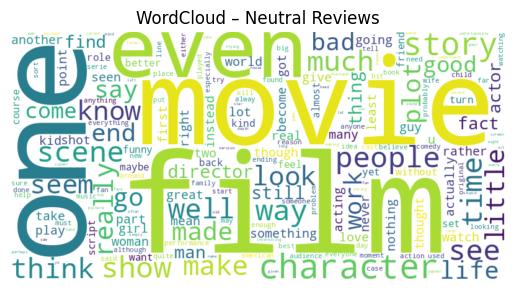

In [34]:
neutral_keywords = []
for kws in df[df['predicted_sentiment'] == 'Neutral']['rake_keywords']:
    neutral_keywords.extend(kws)

generate_wordcloud(neutral_keywords, "WordCloud – Neutral Reviews")
